# Investigation 03 — Schema-family confusion analysis, with focus on VERTICALITY

This notebook examines which image-schema families are easiest or hardest and which labels are confused.

Special focus: VERTICALITY, because earlier analysis suggested it is the weakest substantive schema family.

Thesis use:
- Supports the per-schema results section.
- Links empirical performance to the literature on image-schema definitional ambiguity.
- Provides examples and confusion tables for VERTICALITY.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from the project notebooks/ directory.
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = DATA_DIR / "outputs"
PARSED_PATH = OUTPUTS_DIR / "parsed_responses.jsonl"
RAW_PATH = OUTPUTS_DIR / "raw_responses.jsonl"
GOLD_PATH = DATA_DIR / "gold" / "sentences_v1.jsonl"

EXPORT_DIR = OUTPUTS_DIR / "top4_investigations"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def read_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if line.strip():
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(f"Invalid JSON in {path} line {line_no}: {exc}") from exc
    return pd.DataFrame(rows)

def safe_read_jsonl(path: Path) -> pd.DataFrame:
    return read_jsonl(path) if path.exists() else pd.DataFrame()

def prompt_generation(prompt_id) -> str:
    prompt_id = str(prompt_id)
    if "v2" in prompt_id or "abstention" in prompt_id:
        return "v2_abstention"
    if "v1" in prompt_id:
        return "v1"
    return "unknown"

def prompt_base(prompt_id: str) -> str:
    prompt_id = str(prompt_id)
    if "direct_schema" in prompt_id:
        return "direct_schema"
    if "structured_roles" in prompt_id:
        return "structured_roles"
    if "naive" in prompt_id:
        return "naive"
    return "unknown"

def condition_family_from_id(condition_id) -> str:
    condition_id = str(condition_id)
    if "temp_0" in condition_id:
        return "temp_0"
    if "temp_03" in condition_id:
        return "temp_03"
    if "temp_07" in condition_id:
        return "temp_07"
    return condition_id

def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["prompt_generation"] = out["prompt_id"].map(prompt_generation) if "prompt_id" in out.columns else "unknown"
    out["prompt_base"] = out["prompt_id"].map(prompt_base) if "prompt_id" in out.columns else "unknown"
    out["condition_family_short"] = out["condition_id"].map(condition_family_from_id) if "condition_id" in out.columns else "unknown"
    out["is_control"] = out["sentence_type"].eq("control_weak_schema") if "sentence_type" in out.columns else False
    out["is_non_control"] = ~out["is_control"]

    if "schema_present" not in out.columns:
        out["schema_present"] = np.where(out.get("main_image_schema", pd.Series()).eq("NONE"), "no", "yes")
    out["gold_schema_present"] = np.where(out["is_control"], "no", "yes")

    out["schema_present_correct"] = out["schema_present"].eq(out["gold_schema_present"])
    out["primary_schema_correct"] = out["main_image_schema"].eq(out["expected_schema_primary"])
    out["lm_correct"] = out["literal_or_metaphorical"].eq(out["expected_literal_or_metaphorical"])
    out["control_correct"] = out["is_control"] & out["literal_or_metaphorical"].eq("control") & out["main_image_schema"].eq("NONE")
    out["control_false_positive_schema"] = out["is_control"] & out["main_image_schema"].notna() & ~out["main_image_schema"].eq("NONE")
    out["predicted_none"] = out["main_image_schema"].eq("NONE") | out["literal_or_metaphorical"].eq("control") | out["schema_present"].eq("no")
    return out

def pct(x, digits=1):
    if x is None or pd.isna(x):
        return "NA"
    return f"{100*x:.{digits}f}%"

def save_csv(df: pd.DataFrame, filename: str) -> Path:
    path = EXPORT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Wrote: {path}")
    return path

def display_percent_table(df: pd.DataFrame, percent_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col].map(lambda x: pct(x) if x is not None else "NA")
    return out

parsed_all = add_derived_columns(read_jsonl(PARSED_PATH))
structured = parsed_all[parsed_all["parse_status"].eq("parsed")].copy()

print(f"All parsed records: {len(parsed_all)}")
print(f"Structured records: {len(structured)}")

All parsed records: 9000
Structured records: 7200


In [2]:
# Exclude controls for substantive schema-family analysis, but keep NONE separately for abstention discussion.
schema_data = structured.copy()
non_control = schema_data[~schema_data["is_control"]].copy()
print(f"Structured records: {len(schema_data)}")
print(f"Non-control records: {len(non_control)}")

Structured records: 7200
Non-control records: 4824


In [3]:
# Schema family summary by prompt generation.
schema_summary = (
    schema_data.groupby(["expected_schema_primary", "prompt_generation"])
    .agg(
        n=("run_key", "count"),
        primary_schema_accuracy=("primary_schema_correct", "mean"),
        lm_accuracy=("lm_correct", "mean"),
        schema_present_accuracy=("schema_present_correct", "mean"),
        control_false_positive_rate=("control_false_positive_schema", "mean"),
    )
    .reset_index()
    .sort_values(["expected_schema_primary", "prompt_generation"])
)

save_csv(schema_summary, "schema_family_summary_by_generation.csv")
display(display_percent_table(schema_summary, [
    "primary_schema_accuracy", "lm_accuracy", "schema_present_accuracy", "control_false_positive_rate"
]))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/schema_family_summary_by_generation.csv


,expected_schema_primary,prompt_generation,n,primary_schema_accuracy,lm_accuracy,schema_present_accuracy,control_false_positive_rate
0,BLOCKAGE,v1,396,96.0%,99.0%,99.2%,0.0%
1,BLOCKAGE,v2_abstention,396,98.2%,98.5%,100.0%,0.0%
2,CONTAINER,v1,414,84.5%,100.0%,100.0%,0.0%
3,CONTAINER,v2_abstention,414,87.7%,100.0%,100.0%,0.0%
4,FORCE,v1,396,84.8%,100.0%,100.0%,0.0%
5,FORCE,v2_abstention,396,88.1%,100.0%,100.0%,0.0%
6,NONE,v1,1188,57.3%,57.3%,57.3%,42.7%
7,NONE,v2_abstention,1188,78.4%,78.4%,78.4%,21.6%
8,SOURCE_PATH_GOAL,v1,414,99.5%,100.0%,100.0%,0.0%
9,SOURCE_PATH_GOAL,v2_abstention,414,98.3%,99.0%,99.0%,0.0%


In [4]:
# Confusion matrices by prompt generation.
for generation, g in schema_data.groupby("prompt_generation"):
    print(f"\nConfusion matrix: {generation}")
    matrix = pd.crosstab(
        g["expected_schema_primary"],
        g["main_image_schema"],
        rownames=["gold"],
        colnames=["predicted"],
        dropna=False,
    )
    display(matrix)
    matrix.to_csv(EXPORT_DIR / f"schema_confusion_matrix_{generation}.csv")


Confusion matrix: v1


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,380,0,13,3,0,0,0
CONTAINER,0,350,0,0,63,0,1
FORCE,0,0,336,0,50,0,10
NONE,13,215,73,681,190,2,14
SOURCE_PATH_GOAL,0,2,0,0,412,0,0
SUPPORT_BALANCE,0,2,60,3,0,324,7
VERTICALITY,0,1,2,0,117,18,258



Confusion matrix: v2_abstention


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,389,0,7,0,0,0,0
CONTAINER,2,363,0,0,45,0,4
FORCE,0,0,349,0,36,0,11
NONE,12,124,61,931,46,0,14
SOURCE_PATH_GOAL,0,3,0,4,407,0,0
SUPPORT_BALANCE,0,0,43,0,2,350,1
VERTICALITY,0,0,1,0,102,18,275


In [5]:
# Confusion matrices by prompt_id.
for prompt_id, g in schema_data.groupby("prompt_id"):
    print(f"\nConfusion matrix: {prompt_id}")
    matrix = pd.crosstab(
        g["expected_schema_primary"],
        g["main_image_schema"],
        rownames=["gold"],
        colnames=["predicted"],
        dropna=False,
    )
    display(matrix)
    matrix.to_csv(EXPORT_DIR / f"schema_confusion_matrix_{prompt_id}.csv")


Confusion matrix: p_direct_schema_v1


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,191,0,7,0,0,0,0
CONTAINER,0,190,0,0,17,0,0
FORCE,0,0,169,0,24,0,5
NONE,6,157,38,249,134,2,8
SOURCE_PATH_GOAL,0,2,0,0,205,0,0
SUPPORT_BALANCE,0,2,33,0,0,156,7
VERTICALITY,0,1,0,0,53,9,135



Confusion matrix: p_direct_schema_v2_abstention


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,193,0,5,0,0,0,0
CONTAINER,2,186,0,0,18,0,1
FORCE,0,0,174,0,16,0,8
NONE,6,68,26,466,20,0,8
SOURCE_PATH_GOAL,0,3,0,3,201,0,0
SUPPORT_BALANCE,0,0,16,0,0,181,1
VERTICALITY,0,0,0,0,43,9,146



Confusion matrix: p_structured_roles_v1


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,189,0,6,3,0,0,0
CONTAINER,0,160,0,0,46,0,1
FORCE,0,0,167,0,26,0,5
NONE,7,58,35,432,56,0,6
SOURCE_PATH_GOAL,0,0,0,0,207,0,0
SUPPORT_BALANCE,0,0,27,3,0,168,0
VERTICALITY,0,0,2,0,64,9,123



Confusion matrix: p_structured_roles_v2_abstention


predicted,BLOCKAGE,CONTAINER,FORCE,NONE,SOURCE_PATH_GOAL,SUPPORT_BALANCE,VERTICALITY
gold,,,,,,,
BLOCKAGE,196,0,2,0,0,0,0
CONTAINER,0,177,0,0,27,0,3
FORCE,0,0,175,0,20,0,3
NONE,6,56,35,465,26,0,6
SOURCE_PATH_GOAL,0,0,0,1,206,0,0
SUPPORT_BALANCE,0,0,27,0,2,169,0
VERTICALITY,0,0,1,0,59,9,129


In [6]:
# VERTICALITY-specific errors.
verticality = schema_data[schema_data["expected_schema_primary"].eq("VERTICALITY")].copy()
verticality["verticality_correct"] = verticality["main_image_schema"].eq("VERTICALITY")
print(f"VERTICALITY records: {len(verticality)}")
print(f"VERTICALITY accuracy: {verticality['verticality_correct'].mean():.3f}")

verticality_by_prompt = (
    verticality.groupby(["prompt_id", "prompt_generation", "provider"])
    .agg(
        n=("run_key", "count"),
        verticality_accuracy=("verticality_correct", "mean"),
        most_common_prediction=("main_image_schema", lambda s: s.value_counts().index[0] if len(s.value_counts()) else None),
    )
    .reset_index()
    .sort_values(["prompt_id", "provider"])
)

save_csv(verticality_by_prompt, "verticality_accuracy_by_prompt_provider.csv")
display(display_percent_table(verticality_by_prompt, ["verticality_accuracy"]))

VERTICALITY records: 792
VERTICALITY accuracy: 0.673
Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/verticality_accuracy_by_prompt_provider.csv


,prompt_id,prompt_generation,provider,n,verticality_accuracy,most_common_prediction
0,p_direct_schema_v1,v1,anthropic,66,63.6%,VERTICALITY
1,p_direct_schema_v1,v1,google,66,71.2%,VERTICALITY
2,p_direct_schema_v1,v1,openai,66,69.7%,VERTICALITY
3,p_direct_schema_v2_abstention,v2_abstention,anthropic,66,74.2%,VERTICALITY
4,p_direct_schema_v2_abstention,v2_abstention,google,66,74.2%,VERTICALITY
5,p_direct_schema_v2_abstention,v2_abstention,openai,66,72.7%,VERTICALITY
6,p_structured_roles_v1,v1,anthropic,66,57.6%,VERTICALITY
7,p_structured_roles_v1,v1,google,66,60.6%,VERTICALITY
8,p_structured_roles_v1,v1,openai,66,68.2%,VERTICALITY
9,p_structured_roles_v2_abstention,v2_abstention,anthropic,66,63.6%,VERTICALITY


In [7]:
verticality_errors = verticality[~verticality["verticality_correct"]].copy()

verticality_error_labels = (
    verticality_errors.groupby(["prompt_id", "provider", "main_image_schema"])
    .size()
    .reset_index(name="count")
    .sort_values(["prompt_id", "provider", "count"], ascending=[True, True, False])
)
save_csv(verticality_error_labels, "verticality_error_predicted_labels.csv")
display(verticality_error_labels)

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/verticality_error_predicted_labels.csv


,prompt_id,provider,main_image_schema,count
0,p_direct_schema_v1,anthropic,SOURCE_PATH_GOAL,21
1,p_direct_schema_v1,anthropic,SUPPORT_BALANCE,3
3,p_direct_schema_v1,google,SOURCE_PATH_GOAL,15
4,p_direct_schema_v1,google,SUPPORT_BALANCE,3
2,p_direct_schema_v1,google,CONTAINER,1
5,p_direct_schema_v1,openai,SOURCE_PATH_GOAL,17
6,p_direct_schema_v1,openai,SUPPORT_BALANCE,3
7,p_direct_schema_v2_abstention,anthropic,SOURCE_PATH_GOAL,14
8,p_direct_schema_v2_abstention,anthropic,SUPPORT_BALANCE,3
9,p_direct_schema_v2_abstention,google,SOURCE_PATH_GOAL,14


In [8]:
# Join sentence text and export VERTICALITY error examples.
gold = safe_read_jsonl(GOLD_PATH)
verticality_examples = verticality_errors.copy()

text_col = None
if not gold.empty:
    text_col = "text" if "text" in gold.columns else "sentence" if "sentence" in gold.columns else None
    if text_col:
        verticality_examples = verticality_examples.merge(
            gold[["sentence_id", text_col]].rename(columns={text_col: "sentence_text"}),
            on="sentence_id",
            how="left",
        )

example_cols = [
    "run_key", "provider", "model_id", "prompt_id", "condition_id", "sentence_id",
    "sentence_text" if "sentence_text" in verticality_examples.columns else "sentence_id",
    "expected_schema_primary", "main_image_schema", "literal_or_metaphorical",
    "interpretation", "schema_explanation"
]
example_cols = [c for c in example_cols if c in verticality_examples.columns]

save_csv(verticality_examples[example_cols], "verticality_error_examples.csv")
display(verticality_examples[example_cols].head(30))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/verticality_error_examples.csv


,run_key,provider,model_id,prompt_id,condition_id,sentence_id,sentence_text,expected_schema_primary,main_image_schema,literal_or_metaphorical,interpretation,schema_explanation
0,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_0_v1,s0136,The stone fell into the pond.,VERTICALITY,SOURCE_PATH_GOAL,literal,A stone moved downward and ended up inside the...,Movement follows a path from outside to inside...
1,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_0_v1,s0138,The ladder leaned against the wall.,VERTICALITY,SUPPORT_BALANCE,literal,The ladder is physically resting at an angle a...,The ladder’s stability depends on support from...
2,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_0_v1,s0141,The apple fell from the branch.,VERTICALITY,SOURCE_PATH_GOAL,literal,An apple moved downward away from the branch.,The sentence profiles motion from a source loc...
3,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_0_v1,s0143,The cup slid down the slope.,VERTICALITY,SOURCE_PATH_GOAL,literal,The cup moved downward along the slope.,A moving object follows a path downward; gravi...
4,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_0_v1,s0144,The bird descended toward the field.,VERTICALITY,SOURCE_PATH_GOAL,literal,A bird moved downward in the direction of a fi...,Movement follows a path from a source toward a...
5,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_0_v1,s0145,The climber reached the summit.,VERTICALITY,SOURCE_PATH_GOAL,literal,The climber arrived at the top of the mountain.,Movement along a path ends at a goal; 'summit'...
6,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_03_v1,s0136,The stone fell into the pond.,VERTICALITY,SOURCE_PATH_GOAL,literal,A stone moved downward and ended up inside the...,Movement from one location to another with a g...
7,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_03_v1,s0136,The stone fell into the pond.,VERTICALITY,SOURCE_PATH_GOAL,literal,A stone moved downward and ended up in the pond.,Movement is construed as a path from source to...
8,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_03_v1,s0138,The ladder leaned against the wall.,VERTICALITY,SUPPORT_BALANCE,literal,A ladder is physically resting at an angle aga...,The ladder’s stability depends on support from...
9,openai_gpt_5_4_mini|p_direct_schema_v1|c_temp_...,openai,openai_gpt_5_4_mini,p_direct_schema_v1,c_temp_03_v1,s0138,The ladder leaned against the wall.,VERTICALITY,SUPPORT_BALANCE,literal,The ladder is physically resting at an angle a...,"The ladder is stabilized by the wall, with ver..."


In [9]:
# Which VERTICALITY sentences are hardest?
verticality_sentence = (
    verticality.groupby("sentence_id")
    .agg(
        n=("run_key", "count"),
        correct_n=("verticality_correct", "sum"),
        accuracy=("verticality_correct", "mean"),
        predicted_schemas=("main_image_schema", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
        providers=("provider", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
        prompts=("prompt_id", lambda s: "; ".join(sorted(set(map(str, s.dropna()))))),
    )
    .reset_index()
    .sort_values(["accuracy", "n"], ascending=[True, False])
)

if text_col:
    verticality_sentence = verticality_sentence.merge(
        gold[["sentence_id", text_col]].rename(columns={text_col: "sentence_text"}),
        on="sentence_id",
        how="left",
    )

save_csv(verticality_sentence, "verticality_sentence_difficulty.csv")
display(verticality_sentence.head(30))

Wrote: /Users/Shared/image_schema_llm_project/data/outputs/top4_investigations/verticality_sentence_difficulty.csv


,sentence_id,n,correct_n,accuracy,predicted_schemas,providers,prompts,sentence_text
0,s0136,36,0,0.000000,CONTAINER; SOURCE_PATH_GOAL,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The stone fell into the pond.
1,s0138,36,0,0.000000,SUPPORT_BALANCE,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The ladder leaned against the wall.
2,s0143,36,0,0.000000,SOURCE_PATH_GOAL,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The cup slid down the slope.
3,s0145,36,0,0.000000,SOURCE_PATH_GOAL,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The climber reached the summit.
4,s0144,36,3,0.083333,SOURCE_PATH_GOAL; VERTICALITY,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The bird descended toward the field.
5,s0141,36,6,0.166667,SOURCE_PATH_GOAL; VERTICALITY,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The apple fell from the branch.
6,s0139,36,12,0.333333,SOURCE_PATH_GOAL; VERTICALITY,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The flag dropped to the ground.
7,s0137,36,20,0.555556,SOURCE_PATH_GOAL; VERTICALITY,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The lift went up three floors.
8,s0140,36,31,0.861111,SOURCE_PATH_GOAL; VERTICALITY,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The smoke drifted upward.
9,s0150,36,33,0.916667,FORCE; VERTICALITY,anthropic; google; openai,p_direct_schema_v1; p_direct_schema_v2_abstent...,The scandal brought him down.


prompt_generation,v1,v2_abstention
expected_schema_primary,,
BLOCKAGE,0.959596,0.982323
CONTAINER,0.845411,0.876812
FORCE,0.848485,0.881313
NONE,0.573232,0.783670
SOURCE_PATH_GOAL,0.995169,0.983092
SUPPORT_BALANCE,0.818182,0.883838
VERTICALITY,0.651515,0.694444


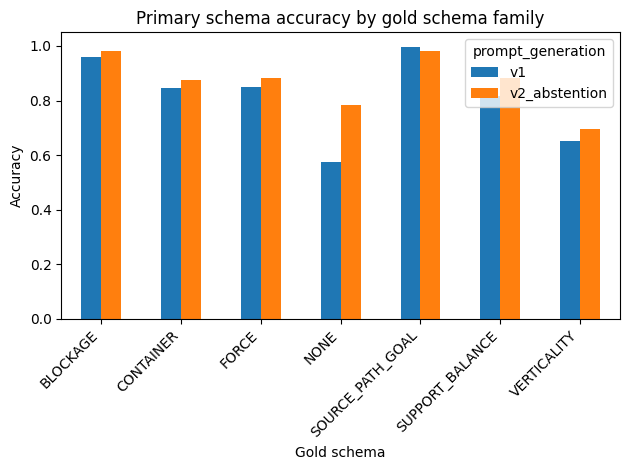

In [10]:
# Plot schema-family primary accuracy.
pivot = schema_summary.pivot_table(
    index="expected_schema_primary",
    columns="prompt_generation",
    values="primary_schema_accuracy"
)
display(pivot)

ax = pivot.plot(kind="bar")
ax.set_title("Primary schema accuracy by gold schema family")
ax.set_xlabel("Gold schema")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Thesis interpretation prompts

Use this notebook to support claims such as:

- The schema inventory is empirically uneven; not all theoretically central schemas are equally recoverable.
- VERTICALITY appears to be a difficult family and should be discussed as a case of scalar/orientational ambiguity.
- If VERTICALITY is often confused with SOURCE_PATH_GOAL, that may indicate a change/path construal.
- If VERTICALITY is confused with SUPPORT_BALANCE, that may indicate evaluative or stability readings.
- If VERTICALITY is confused with FORCE, that may indicate causal intensity or pressure readings.

The most useful thesis examples will be sentence-level VERTICALITY errors with model explanations.